# Chip calibration — QICK Workspace V2

This notebook contains SDK imports, editable parameters and SDK execution calls. Pulse sequences, analysis, final plots, data persistence, scan loops and interruption recovery are maintained by the SDK.

Edit each tuning block, then run its acquisition cell. `lab.run(Program, run_cfg)` automatically acquires, analyzes and shows the saved result. `lab.scan(...)` does the same for a host sweep; readout frequency coordinates are resolved automatically from the compiled hardware configuration. Use `lab.analyze(result)` to rerun analysis on saved data after editing `QickworkspaceV2/analysis/fitting.py`.

Working calibration writes are disabled initially (`calibration_enabled=False`), suitable for the current no-chip setup. Enable them after connecting a chip and reviewing measured fits; the separate apply cells still require completed, accepted results. External flux remains opt-in. Frequencies are MHz, times us, phases degrees (fit-function phases radians), gains normalized QICK units.

The final interruption section requests a long acquisition: press Interrupt after acquisition has started. The SDK retains and analyzes the current partial data. Earlier user outputs are preserved when updating this notebook.

In [1]:
from QickworkspaceV2.notebook import enable_notebook
enable_notebook()

In [2]:
from QickworkspaceV2 import NotebookLab, QickSweep1D, linspace

## 0. Chip, working settings and connection

Load the saved working calibration when present. Edits below are Python working values; hardware profiles are not rewritten.

In [3]:
qubit = "Q1"
lab = NotebookLab("lab/project.yaml", qubit=qubit, data_path="data",
                  working_config="lab/working_config.yaml", calibration_enabled=False)
qb = lab.config[qubit]
PY_AVG = 500
# Edit these values for the selected chip. Every run receives an independent copy.
qb.update({
    "res_freq_ge": qb["res_freq_ge"],
    "res_gain_ge": qb["res_gain_ge"],
    "res_pulse_type": qb["res_pulse_type"],  # const / arb / flat_top
    "res_sigma": qb["res_sigma"],            # used by arb / flat_top readout
    "res_length": qb["res_length"],
    "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"],
    "res_phase": qb["res_phase"],            # transmitted readout phase
    "ro_phase": qb["ro_phase"],              # software IQ rotation, degrees
    "ro_threshold": qb["ro_threshold"],      # None = train from g/e shots
    "qb_freq_ge": qb["qb_freq_ge"], "qb_freq_ef": qb["qb_freq_ef"],
    "sigma_ge": qb["sigma_ge"], "sigma_ef": qb["sigma_ef"],
    "pulse_type_ge": qb["pulse_type_ge"], "pulse_type_ef": qb["pulse_type_ef"],
    "pi_gain_ge": qb["pi_gain_ge"], "pi2_gain_ge": qb["pi2_gain_ge"],
    "pi_gain_ef": qb["pi_gain_ef"], "pi2_gain_ef": qb["pi2_gain_ef"],
    "reps": qb["reps"], "relax_delay": qb["relax_delay"],
    "iq_process": "abs",
})
lab.show_settings()

{'reps': 100,
 'relax_delay': 200.0,
 'soft_avgs': 1,
 'iq_process': 'abs',
 'steps': 81,
 'reset_wait_us': 200.0,
 'detuning_mhz': 0.2,
 'name': 'Q1',
 'namespace': 'Q1',
 'ro_ch': 0,
 'res_ch': 2,
 'nqz_res': 2,
 'res_mixer': 0.0,
 'readout_group': 'R1',
 'readout_mode': 'direct',
 'res_freq_ge': 6717.0,
 'res_gain_ge': 0.2,
 'res_phase': 0.0,
 'ro_phase': 0.0,
 'ro_threshold': None,
 'tone_slot': 0,
 'res_length': 5.0,
 'res_pulse_type': 'const',
 'res_sigma': 0.02,
 'res_length_mult': 5.0,
 'ro_length': 4.0,
 'trig_time': 0.5,
 'pins': [],
 'cooling': False,
 'transition': 'ge',
 'qb_ch': 0,
 'nqz_qb': 1,
 'qb_mixer': 2872.649825,
 'qb_freq_ge': 2872.649825,
 'qb_gain_ge': 0.1,
 'pi_gain_ge': 0.1,
 'pi2_gain_ge': 0.05,
 'sigma_ge': 0.05,
 'length_mult_ge': 5.0,
 'qb_phase_ge': 0.0,
 'pulse_type_ge': 'arb',
 'shape_ge': 'gauss',
 'qb_length_ge': 0.1,
 'qb_flat_top_length_ge': 0.1,
 'drag_alpha_ge': None,
 'drag_delta_ge': None,
 'qb_ch_ef': 0,
 'nqz_qb_ef': 1,
 'qb_mixer_ef': 2872.6

In [4]:
lab.connect(ns_host="192.168.10.82", ns_port=8888, proxy_name="myqick")

QICK library version mismatch: 0.2.381 remote (the board), 0.2.405 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_7206e4b5e1944ef4a3e0d9d4cadf23cb@192.168.10.82:40951
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Sun Aug 10 18:48:22 2025):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-

## 1. TOF and readout timing

Use g first. `check_e` prepares e; `check_f` prepares f with GE then EF pi pulses. Select only one. `tof_threshold` is an absolute envelope threshold, distinct from the single-shot classifier threshold.

In [5]:
from QickworkspaceV2.experiments.time_of_flight import TimeOfFlightProgram
Program = TimeOfFlightProgram
run_cfg = qb.for_run()
run_cfg.update({
    "reps": 1, "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_pulse_type": "const", "res_sigma": qb["res_sigma"],
    "res_length": 0.5, "ro_length": 3.0, "trig_time": 0.0,
    "check_e": False, "check_f": False, "prepare_delay_us": 0.05,
    "tof_threshold": None, "relax_delay": 1,
})

Interrupted; retained current run: 5d925bec285a4e038ea09b78d310cc41 C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\5d925bec285a4e038ea09b78d310cc41\partial.h5
Run: 5d925bec285a4e038ea09b78d310cc41 Data: C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\5d925bec285a4e038ea09b78d310cc41\partial.h5
Acquisition: partial
Analysis: completed Q1: Envelope diagnostic only; inspect the trace before adjusting trigger timing
Q1 tof_diagnostic REVIEW {'peak_amplitude': 0.5738350135108099, 'peak_time_us': 1.044921875} {} Envelope diagnostic only; inspect the trace before adjusting trigger timing


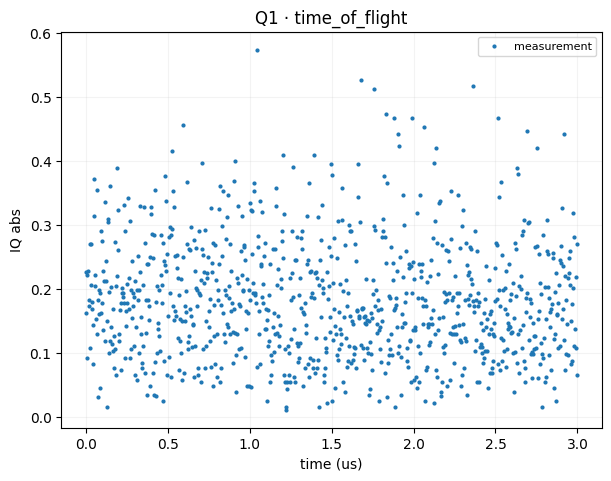

In [6]:
tof_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(tof_result)


In [ ]:
TRIGGER_US = qb["trig_time"]
INTEGRATION_US = qb["ro_length"]
lab.update_working(trig_time=TRIGGER_US, ro_length=INTEGRATION_US)

## 2. Broadband resonator spectrum

Use the independent BroadbandResonatorSpecProgram experiment. It shares the native one-tone hardware sequence with the narrow spectrum; its own analyzer preserves the original smoothed dip detector, phase-reference refinement and three-point quadratic interpolation. Set count and detection_options below, then select and verify a resonance with the separate narrow experiment.

In [7]:
from QickworkspaceV2.experiments.broadband_resonator_spectrum import BroadbandResonatorSpecProgram
Program = BroadbandResonatorSpecProgram
run_cfg = qb.for_run(res_freq_ge=qb["res_freq_ge"], res_gain_ge=qb["res_gain_ge"],
                     res_sigma=qb["res_sigma"], res_length=qb["res_length"],
                     ro_length=qb["ro_length"], ro_threshold=None, reps=100, relax_delay=0)
START_FREQ, STOP_FREQ, STEPS = 6600.0, 7000.0, 401
NUMBER_OF_RESONATORS = 4
run_cfg.update(steps=STEPS, res_freq_ge=QickSweep1D("freqloop", START_FREQ, STOP_FREQ))
run_cfg.update({
    "count": NUMBER_OF_RESONATORS, "y_mode": "abs",  # abs / db / phase
    "detection_options": {
        "min_distance_points": 6, "prominence_sigma": 0.08, "width_penalty": 0.5,
        "use_phase_reference": True, "phase_snap_hz": 15e6,
    },
})


Interrupted; retained current run: 79f7405c7e404ce59253022b182a70d6 C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\79f7405c7e404ce59253022b182a70d6\partial.h5
Run: 79f7405c7e404ce59253022b182a70d6 Data: C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\79f7405c7e404ce59253022b182a70d6\partial.h5
Acquisition: partial
Analysis: completed 
Q1 broadband PASS {'resonance_1_mhz': 6602.999934196472, 'resonance_2_mhz': 6752.996787071228, 'resonance_3_mhz': 6767.180563740194, 'resonance_4_mhz': 6997.520758861504} {} Located 4 resonators using phase-referenced dip detection and quadratic interpolation; verify a selected resonance in a narrow sweep.


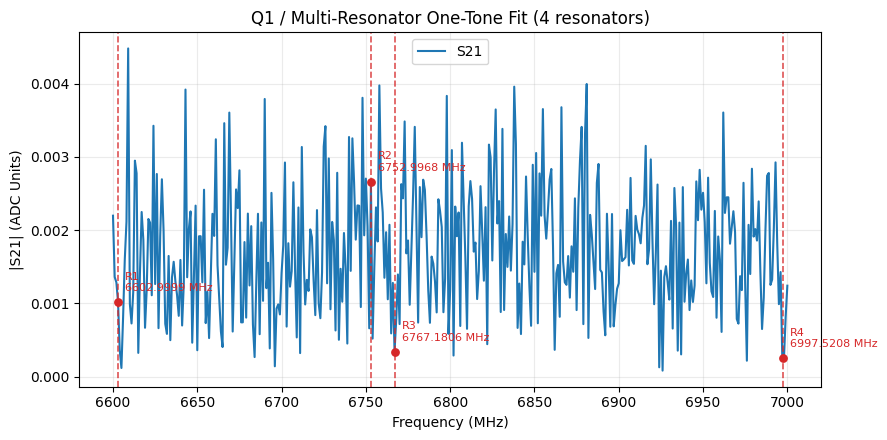

In [8]:
broadband_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(broadband_result)


In [9]:
SELECTED_READOUT_MHZ = qb["res_freq_ge"]
lab.update_working(res_freq_ge=SELECTED_READOUT_MHZ)

Working calibration writes disabled


## 3. Narrow readout resonance

Choose magnitude Lorentzian or complex-notch analysis. Complex-notch fitting assumes a calibrated transmission notch; it is not appropriate for every wiring response.

In [10]:
from QickworkspaceV2.experiments.resonator_spec import ResonatorSpecProgram
Program = ResonatorSpecProgram
STEPS = 101
START_FREQ, STOP_FREQ = qb["res_freq_ge"] - 5, qb["res_freq_ge"] + 5
run_cfg = qb.for_run(steps=STEPS, res_freq_ge=QickSweep1D("freqloop", START_FREQ, STOP_FREQ),
                     res_gain_ge=qb["res_gain_ge"], res_pulse_type=qb["res_pulse_type"],
                     res_sigma=qb["res_sigma"], res_length=qb["res_length"],
                     ro_length=qb["ro_length"], trig_time=qb["trig_time"], ro_threshold=None,
                     reps=100, relax_delay=0)
READOUT_FIT = "lorentzian"  # lorentzian / complex_notch
run_cfg["fit"] = {"model": READOUT_FIT}  # Optional p0/bounds are configured in SDK analysis/fitting.py

Interrupted; retained current run: 2d96f5af56464123b8cd82d027b1b60f C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\2d96f5af56464123b8cd82d027b1b60f\partial.h5
Run: 2d96f5af56464123b8cd82d027b1b60f Data: C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\2d96f5af56464123b8cd82d027b1b60f\partial.h5
Acquisition: partial
Analysis: completed Q1: R² 0.138 below 0.800; width is poorly constrained
Q1 lorentzian REVIEW {'offset': 0.004374797089894673, 'amplitude': 0.036939429994643794, 'center': 6713.064918634939, 'width': 0.009999790191614424, 'fwhm': 0.019999580383228847} {'offset': 7.621320639106763e-05, 'amplitude': 2.4625026203313958, 'center': 0.04625117218683705, 'width': 0.347518857587556, 'fwhm': 0.695037715175112} R² 0.138 below 0.800; width is poorly constrained


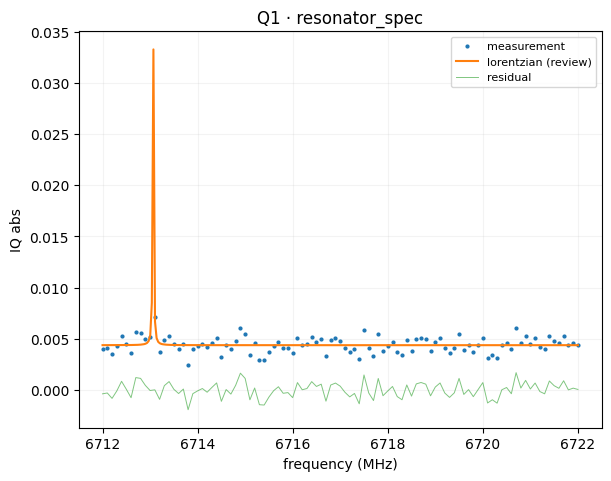

In [11]:
readout_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(readout_result)


In [12]:
lab.apply_fit(readout_result)

Working calibration writes disabled; acquired data and analysis remain saved


False

## 4. Readout punchout

The FPGA sweeps gain in the outer loop and frequency in the inner loop. One run stores a gain-by-frequency IQ map with compiled coordinates. LivePlot shows the accumulating map; the SDK clears it before the final heatmap. Inspect the map to select readout power; no automatic calibration is applied.

In [6]:
from QickworkspaceV2.experiments.resonator_punchout import PunchoutProgram

Program = PunchoutProgram
F_STEPS, G_STEPS = 101, 11
START_FREQ, STOP_FREQ = qb["res_freq_ge"] - 10, qb["res_freq_ge"] + 10
START_GAIN, STOP_GAIN = 0.02, 0.2
run_cfg = qb.for_run(
    f_steps=F_STEPS,
    g_steps=G_STEPS,
    res_freq_ge=QickSweep1D("freqloop", START_FREQ, STOP_FREQ),
    res_gain_ge=QickSweep1D("gainloop", START_GAIN, STOP_GAIN),
    res_sigma=qb["res_sigma"],
    ro_length=qb["ro_length"],
    reps=100,
    relax_delay=0,
)


Interrupted; retained current run: 1d4c302d8bf24269bf6428aa59c1fac0 C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\1d4c302d8bf24269bf6428aa59c1fac0\partial.h5
Run: 1d4c302d8bf24269bf6428aa59c1fac0 Data: C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\1d4c302d8bf24269bf6428aa59c1fac0\partial.h5
Acquisition: partial
Analysis: completed Q1: Data summary only; no physical calibration inferred from this map
Q1 signal_summary REVIEW {'min_amplitude': 2.558714708992856e-05, 'max_amplitude': 0.00676255605436933, 'amplitude_span': 0.006736968907279401} {} Data summary only; no physical calibration inferred from this map


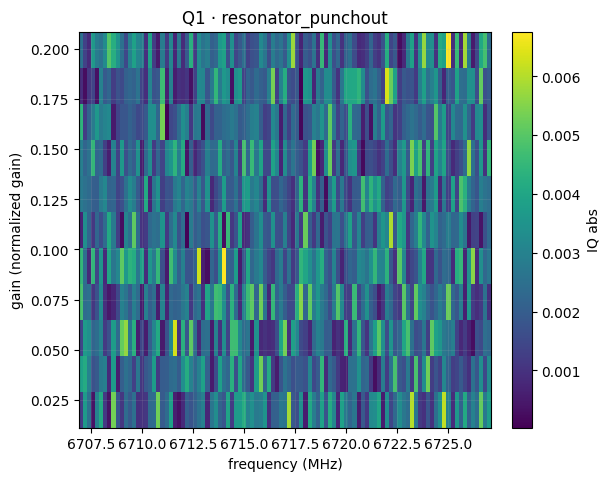

In [7]:
punchout_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(punchout_result)


## GE spectrum

Edit this run's settings; apply fitted values only from the separate update cell.

In [8]:
from QickworkspaceV2.experiments.qubit_spec_ge import QubitSpecGEProgram
Program = QubitSpecGEProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ge": qb["sigma_ge"],
    "pulse_type_ge": qb["pulse_type_ge"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_FREQ, STOP_FREQ = qb["qb_freq_ge"]-20, qb["qb_freq_ge"]+20
run_cfg.update(steps=STEPS, qb_freq_ge=QickSweep1D("freqloop", START_FREQ, STOP_FREQ),
               qb_gain_ge=0.05, qb_flat_top_length_ge=2.0)

Interrupted; retained current run: bc684923a41f4c0e9e7aa6f3ea487137 C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\bc684923a41f4c0e9e7aa6f3ea487137\partial.h5
Run: bc684923a41f4c0e9e7aa6f3ea487137 Data: C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\bc684923a41f4c0e9e7aa6f3ea487137\partial.h5
Acquisition: partial
Analysis: completed Q1: R² 0.103 below 0.800; width is poorly constrained
Q1 lorentzian REVIEW {'offset': 0.013665048423870209, 'amplitude': 0.010606608155911015, 'center': 2872.3100250032176, 'width': 0.16696801501661063, 'fwhm': 0.33393603003322125} {'offset': 0.00029641485626384834, 'amplitude': 0.014967527626550558, 'center': 0.284496041866835, 'width': 0.24126624326739163, 'fwhm': 0.48253248653478326} R² 0.103 below 0.800; width is poorly constrained


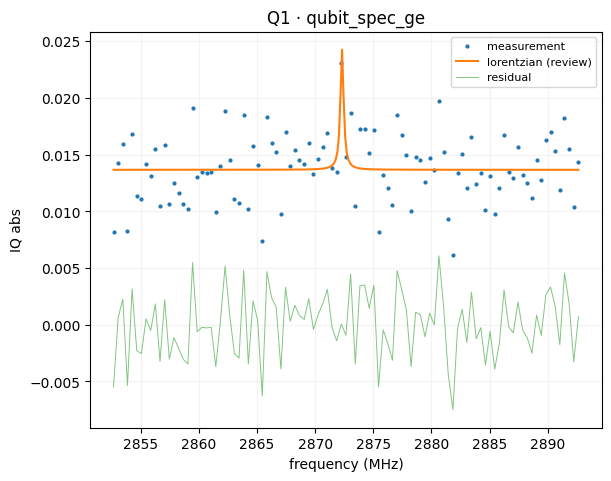

In [9]:
qubit_spec_ge_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(qubit_spec_ge_result)


In [10]:
lab.apply_fit(qubit_spec_ge_result)

Working calibration writes disabled; acquired data and analysis remain saved


False

## GE time rabi

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.time_rabi_ge import TimeRabiGEProgram
Program = TimeRabiGEProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ge": qb["sigma_ge"],
    "pulse_type_ge": qb["pulse_type_ge"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_TIME, STOP_TIME = 0.02, 2.0
# This protocol deliberately sweeps a constant-pulse duration; sigma does not change that pulse.
run_cfg.update(steps=STEPS, qb_length_ge=QickSweep1D("lengthloop", START_TIME, STOP_TIME),
               qb_gain_ge=0.15)

In [ ]:
time_rabi_ge_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(time_rabi_ge_result)


## GE power rabi

Edit this run's settings; apply fitted values only from the separate update cell.

In [11]:
from QickworkspaceV2.experiments.power_rabi_ge import PowerRabiGEProgram
Program = PowerRabiGEProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ge": qb["sigma_ge"],
    "pulse_type_ge": qb["pulse_type_ge"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_GAIN, STOP_GAIN = 0.0, 0.45
run_cfg.update(steps=STEPS, qb_gain_ge=QickSweep1D("gainloop", START_GAIN, STOP_GAIN))

Interrupted; retained current run: 0128f5d2843c4b1f959d847cc063a20f C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\0128f5d2843c4b1f959d847cc063a20f\partial.h5
Run: 0128f5d2843c4b1f959d847cc063a20f Data: C:\Users\cluster\Desktop\Quantum-AI\QickworksaceV2\data\0128f5d2843c4b1f959d847cc063a20f\partial.h5
Acquisition: partial
Analysis: completed Q1: R² 0.069 below 0.800
Q1 rabi REVIEW {'offset': 0.01306377797329145, 'amplitude': 0.0011959568517496673, 'frequency': 22.380087667560396, 'phase': -3.0540715007718795, 'pi_gain': 0.02234128871285623, 'pi2_gain': 0.011170644356428115} {'offset': 0.000317120176368481, 'amplitude': 0.00044484305282004976, 'frequency': 0.46477522761796053, 'phase': 0.7530377142189899, 'pi_gain': 0.00046396947594835896, 'pi2_gain': 0.00023198473797417948} R² 0.069 below 0.800


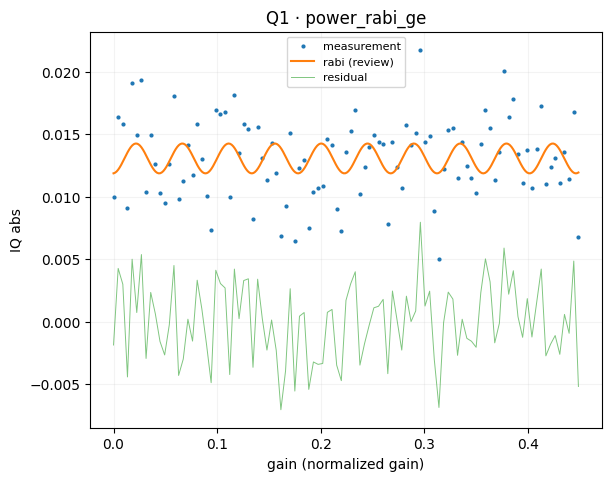

In [12]:
power_rabi_ge_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(power_rabi_ge_result)


In [ ]:
lab.apply_fit(power_rabi_ge_result)

## GE g/e readout calibration

None trains rotation and threshold on alternating shots and reports held-out fidelity. A numeric ro_threshold evaluates your explicitly selected rotated-I discriminator. Stored IQ remains unchanged.

In [ ]:
from QickworkspaceV2.experiments.single_shot import SingleShotProgram
Program = SingleShotProgram
run_cfg = qb.for_run(reps=2000, reset_wait_us=200, relax_delay=200,
                     res_gain_ge=qb["res_gain_ge"], res_sigma=qb["res_sigma"],
                     res_length=qb["res_length"], ro_length=qb["ro_length"],
                     res_phase=qb["res_phase"], ro_phase=qb["ro_phase"], ro_threshold=None)

In [ ]:
single_shot_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(single_shot_result)


In [ ]:
lab.apply_fit(single_shot_result)

## Readout gain / integration-length optimization

Every grid point is a fresh paired g/e measurement. Choose only a point whose measured held-out assignment fit passes. No settings are changed by the sweep itself.

In [ ]:
Program = SingleShotProgram
run_cfg = qb.for_run(reps=2000, reset_wait_us=200, ro_threshold=None)
GAIN_VALUES = linspace(0.05, 0.15, 5)
LENGTH_VALUES_US = linspace(1, 5, 5)
RO_END_MARGIN_US = 0.1

In [ ]:
readout_grid = lab.readout_grid(Program, run_cfg, GAIN_VALUES, LENGTH_VALUES_US,
                               margin_us=RO_END_MARGIN_US, py_avg=PY_AVG)
lab.save_labber(readout_grid)


In [ ]:
lab.apply_best_readout(readout_grid)

## Dispersive shift and best readout frequency

Paired g/e shots at each readout frequency give measured state separation and noise. Inspect both response curves; the selected frequency maximizes measured SNR within the configured range.

In [ ]:
from QickworkspaceV2.experiments.dispersive import DispersiveProgram

In [ ]:
Program = DispersiveProgram
run_cfg = qb.for_run(steps=51, res_freq_ge=QickSweep1D("freqloop", qb["res_freq_ge"]-5, qb["res_freq_ge"]+5),
                     reps=200, reset_wait_us=200, res_sigma=qb["res_sigma"], ro_threshold=None)

In [ ]:
dispersive_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(dispersive_result)


In [ ]:
lab.apply_fit(dispersive_result)

## GE t1

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.t1_ge import T1GEProgram
Program = T1GEProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ge": qb["sigma_ge"],
    "pulse_type_ge": qb["pulse_type_ge"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_TIME, STOP_TIME = 0.0, 100.0
run_cfg.update(steps=STEPS, wait_us=QickSweep1D("waitloop", START_TIME, STOP_TIME), detuning_mhz=0.2)

In [ ]:
t1_ge_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(t1_ge_result)


In [ ]:
lab.apply_fit(t1_ge_result)

## GE ramsey

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.ramsey_ge import RamseyGEProgram
Program = RamseyGEProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ge": qb["sigma_ge"],
    "pulse_type_ge": qb["pulse_type_ge"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_TIME, STOP_TIME = 0.0, 100.0
run_cfg.update(steps=STEPS, wait_us=QickSweep1D("waitloop", START_TIME, STOP_TIME), detuning_mhz=0.2)

In [ ]:
ramsey_ge_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(ramsey_ge_result)


In [ ]:
lab.apply_fit(ramsey_ge_result)

## GE echo

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.spin_echo_ge import SpinEchoGEProgram
Program = SpinEchoGEProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ge": qb["sigma_ge"],
    "pulse_type_ge": qb["pulse_type_ge"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_TIME, STOP_TIME = 0.0, 100.0
run_cfg.update(steps=STEPS, wait_us=QickSweep1D("waitloop", START_TIME, STOP_TIME), detuning_mhz=0.2)

In [ ]:
spin_echo_ge_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(spin_echo_ge_result)


In [ ]:
lab.apply_fit(spin_echo_ge_result)

## Signed GE frequency refinement

Two Ramsey runs with zero artificial detuning and opposite known drive offsets resolve the absolute-frequency ambiguity. Both fits must pass before applying the inferred center.

In [ ]:
from QickworkspaceV2.experiments.ramsey_ge import RamseyGEProgram
Program = RamseyGEProgram
CENTER_GE_MHZ = qb["qb_freq_ge"]
DRIVE_OFFSET_MHZ = 0.2
run_cfg = qb.for_run(steps=101, wait_us=QickSweep1D("waitloop", 0, 30), detuning_mhz=0,
                     qb_freq_ge=CENTER_GE_MHZ, sigma_ge=qb["sigma_ge"], relax_delay=200)

In [ ]:
ramsey_offsets = lab.ramsey_pair(Program, run_cfg, center=CENTER_GE_MHZ,
                                 offset=DRIVE_OFFSET_MHZ, py_avg=PY_AVG)
lab.save_labber(ramsey_offsets)


In [ ]:
lab.apply_ramsey_pair(ramsey_offsets)

## EF spectrum

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.qubit_spec_ef import QubitSpecEFProgram
Program = QubitSpecEFProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ef": qb["sigma_ef"],
    "pulse_type_ef": qb["pulse_type_ef"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_FREQ, STOP_FREQ = qb["qb_freq_ef"]-20, qb["qb_freq_ef"]+20
run_cfg.update(steps=STEPS, qb_freq_ef=QickSweep1D("freqloop", START_FREQ, STOP_FREQ),
               qb_gain_ef=0.05, qb_flat_top_length_ef=2.0)

In [ ]:
qubit_spec_ef_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(qubit_spec_ef_result)


In [ ]:
lab.apply_fit(qubit_spec_ef_result)

## EF time rabi

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.time_rabi_ef import TimeRabiEFProgram
Program = TimeRabiEFProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ef": qb["sigma_ef"],
    "pulse_type_ef": qb["pulse_type_ef"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_TIME, STOP_TIME = 0.02, 2.0
# This protocol deliberately sweeps a constant-pulse duration; sigma does not change that pulse.
run_cfg.update(steps=STEPS, qb_length_ef=QickSweep1D("lengthloop", START_TIME, STOP_TIME),
               qb_gain_ef=0.15)

In [ ]:
time_rabi_ef_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(time_rabi_ef_result)


## EF power rabi

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.power_rabi_ef import PowerRabiEFProgram
Program = PowerRabiEFProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ef": qb["sigma_ef"],
    "pulse_type_ef": qb["pulse_type_ef"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_GAIN, STOP_GAIN = 0.0, 0.45
run_cfg.update(steps=STEPS, qb_gain_ef=QickSweep1D("gainloop", START_GAIN, STOP_GAIN))

In [ ]:
power_rabi_ef_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(power_rabi_ef_result)


In [ ]:
lab.apply_fit(power_rabi_ef_result)

## EF t1

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.t1_ef import T1EFProgram
Program = T1EFProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ef": qb["sigma_ef"],
    "pulse_type_ef": qb["pulse_type_ef"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_TIME, STOP_TIME = 0.0, 100.0
run_cfg.update(steps=STEPS, wait_us=QickSweep1D("waitloop", START_TIME, STOP_TIME), detuning_mhz=0.2)

In [ ]:
t1_ef_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(t1_ef_result)


In [ ]:
lab.apply_fit(t1_ef_result)

## EF ramsey

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.ramsey_ef import RamseyEFProgram
Program = RamseyEFProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ef": qb["sigma_ef"],
    "pulse_type_ef": qb["pulse_type_ef"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_TIME, STOP_TIME = 0.0, 100.0
run_cfg.update(steps=STEPS, wait_us=QickSweep1D("waitloop", START_TIME, STOP_TIME), detuning_mhz=0.2)

In [ ]:
ramsey_ef_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(ramsey_ef_result)


In [ ]:
lab.apply_fit(ramsey_ef_result)

## EF echo

Edit this run's settings; apply fitted values only from the separate update cell.

In [ ]:
from QickworkspaceV2.experiments.spin_echo_ef import SpinEchoEFProgram
Program = SpinEchoEFProgram
run_cfg = qb.for_run()
run_cfg.update({
    "res_freq_ge": qb["res_freq_ge"], "res_gain_ge": qb["res_gain_ge"],
    "res_sigma": qb["res_sigma"], "res_length": qb["res_length"], "ro_length": qb["ro_length"],
    "trig_time": qb["trig_time"], "res_phase": qb["res_phase"], "ro_phase": qb["ro_phase"],
    "ro_threshold": qb["ro_threshold"], "sigma_ef": qb["sigma_ef"],
    "pulse_type_ef": qb["pulse_type_ef"], "reps": 100, "relax_delay": 200,
})
STEPS = 101
START_TIME, STOP_TIME = 0.0, 100.0
run_cfg.update(steps=STEPS, wait_us=QickSweep1D("waitloop", START_TIME, STOP_TIME), detuning_mhz=0.2)

In [ ]:
spin_echo_ef_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(spin_echo_ef_result)


In [ ]:
lab.apply_fit(spin_echo_ef_result)

## Readout resonance after preparing e

In [ ]:
from QickworkspaceV2.experiments.resonator_spec_e import ResonatorSpecEProgram
Program = ResonatorSpecEProgram
run_cfg = qb.for_run(steps=101, res_freq_ge=QickSweep1D("freqloop", qb["res_freq_ge"]-5, qb["res_freq_ge"]+5),
                     res_gain_ge=qb["res_gain_ge"], res_sigma=qb["res_sigma"], relax_delay=200)

In [ ]:
readout_e_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(readout_e_result)


## Readout resonance after preparing f

In [ ]:
from QickworkspaceV2.experiments.resonator_spec_f import ResonatorSpecFProgram
Program = ResonatorSpecFProgram
run_cfg = qb.for_run(steps=101, res_freq_ge=QickSweep1D("freqloop", qb["res_freq_ge"]-5, qb["res_freq_ge"]+5),
                     res_gain_ge=qb["res_gain_ge"], res_sigma=qb["res_sigma"], relax_delay=200)

In [ ]:
readout_f_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(readout_f_result)


## Three-state g/e/f readout

Use calibrated GE and EF pi pulses. All three labeled shot clouds and the held-out confusion matrix are retained.

In [ ]:
from QickworkspaceV2.experiments.single_shot_gef import SingleShotGEFProgram
Program = SingleShotGEFProgram
run_cfg = qb.for_run(reps=2000, reset_wait_us=300, res_sigma=qb["res_sigma"], ro_threshold=None)

In [ ]:
single_shot_gef_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(single_shot_gef_result)


## Thermal population from EF Rabi

Paired thermal/prepared EF amplitude fits assume negligible f population, equal EF response and calibrated GE inversion. A failed low-amplitude trace is reported; it is not converted into a temperature.

In [ ]:
from QickworkspaceV2.experiments.qubit_temperature import QubitTemperatureProgram
Program = QubitTemperatureProgram
run_cfg = qb.for_run(steps=101, qb_gain_ef=QickSweep1D("gainloop", 0, 0.45),
                     reset_wait_us=500, sigma_ef=qb["sigma_ef"], reps=500, relax_delay=500)

In [ ]:
temperature_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(temperature_result)


## GE amplified amplitude error / repeated Rabi

Inspect fitted pi-gain estimates versus repetition count; verify the chosen correction in a single-pulse Rabi before writing it back.

In [ ]:
from QickworkspaceV2.experiments.power_rabi_chevron_ge import PowerRabiChevronGEProgram
Program = PowerRabiChevronGEProgram
run_cfg = qb.for_run(steps=81, qb_gain_ge=QickSweep1D("gainloop", 0.01, 0.3), iterations=1,
                     sigma_ge=qb["sigma_ge"], relax_delay=200)
ITERATIONS = [1, 3, 5, 7]

In [ ]:
repeated_ge_result = lab.scan(Program, run_cfg, "iterations", ITERATIONS, py_avg=PY_AVG)
lab.save_labber(repeated_ge_result)


## GE DRAG alpha calibration

The selected alpha minimizes the measured return-error signal. Inspect the full curve and reference contrast before accepting it.

In [ ]:
from QickworkspaceV2.experiments.drag_ge import DragGEProgram
Program = DragGEProgram
DELTA_MHZ = qb["qb_freq_ef"] - qb["qb_freq_ge"]
ALPHAS = linspace(-0.5, 0.5, 11)
run_cfg = qb.for_run(alpha=0, iterations=5, reset_wait_us=200, drag_alpha_ge=0,
                     drag_delta_ge=DELTA_MHZ, sigma_ge=qb["sigma_ge"], reps=100)

In [ ]:
drag_ge_runs = lab.drag_scan(Program, run_cfg, ALPHAS, py_avg=PY_AVG)
lab.save_labber(drag_ge_runs)


In [ ]:
lab.apply_best_drag(drag_ge_runs)

## EF amplified amplitude error / repeated Rabi

Inspect fitted pi-gain estimates versus repetition count; verify the chosen correction in a single-pulse Rabi before writing it back.

In [ ]:
from QickworkspaceV2.experiments.power_rabi_chevron_ef import PowerRabiChevronEFProgram
Program = PowerRabiChevronEFProgram
run_cfg = qb.for_run(steps=81, qb_gain_ef=QickSweep1D("gainloop", 0.01, 0.3), iterations=1,
                     sigma_ef=qb["sigma_ef"], relax_delay=200)
ITERATIONS = [1, 3, 5, 7]

In [ ]:
repeated_ef_result = lab.scan(Program, run_cfg, "iterations", ITERATIONS, py_avg=PY_AVG)
lab.save_labber(repeated_ef_result)


## EF DRAG alpha calibration

The selected alpha minimizes the measured return-error signal. Inspect the full curve and reference contrast before accepting it.

In [ ]:
from QickworkspaceV2.experiments.drag_ef import DragEFProgram
Program = DragEFProgram
DELTA_MHZ = qb["qb_freq_ef"] - qb["qb_freq_ge"]
ALPHAS = linspace(-0.5, 0.5, 11)
run_cfg = qb.for_run(alpha=0, iterations=5, reset_wait_us=200, drag_alpha_ef=0,
                     drag_delta_ef=DELTA_MHZ, sigma_ef=qb["sigma_ef"], reps=100)

In [ ]:
drag_ef_runs = lab.drag_scan(Program, run_cfg, ALPHAS, py_avg=PY_AVG)
lab.save_labber(drag_ef_runs)


In [ ]:
lab.apply_best_drag(drag_ef_runs)

## AllXY pulse validation

Run after GE Rabi and again after DRAG updates. This reports endpoint-normalized sequence error, not gate fidelity.

In [ ]:
from QickworkspaceV2.experiments.allxy import AllXYProgram
Program = AllXYProgram
run_cfg = qb.for_run(reset_wait_us=200, reps=500, sigma_ge=qb["sigma_ge"],
                     pulse_type_ge=qb["pulse_type_ge"], shape_ge=qb["shape_ge"])

In [ ]:
allxy_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(allxy_result)


## Randomized and interleaved benchmarking

Run a reference with interleaved="none", then repeat for a selected native gate. Use multiple random sequences. Keep the program within board instruction memory; increase depth gradually.

In [ ]:
from QickworkspaceV2.experiments.randomized_benchmarking import RBProgram
Program = RBProgram
run_cfg = qb.for_run(reset_wait_us=200, reps=100, sigma_ge=qb["sigma_ge"],
                     depths=[0, 1, 2, 4, 8, 12, 16], sequences_per_depth=2, seed=42,
                     interleaved="none")  # none / x / y / halfx / halfy / mhalfx / mhalfy

In [ ]:
rb_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(rb_result)


## Single-qubit state tomography

Uses retained shots and the calibrated software rotation/threshold. Linear inversion reports its minimum eigenvalue; no silent positivity projection or assignment correction is applied.

In [ ]:
from QickworkspaceV2.experiments.state_tomography import StateTomographyProgram
Program = StateTomographyProgram
run_cfg = qb.for_run(reps=2000, reset_wait_us=200, ro_threshold=qb["ro_threshold"],
                     ro_phase=qb["ro_phase"], preparation="plus")  # ground / excited / plus

In [ ]:
tomography_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(tomography_result)


## Raw I/Q threshold calibration for hardware feedback

The tProc compares raw I or Q, not an arbitrary software-rotated projection. Measure the selected axis and inspect fidelity before enabling reset. The software classifier threshold is retained separately in the run record.

In [ ]:
Program = SingleShotProgram
FEEDBACK_COMPONENT = "I"  # I / Q
run_cfg = qb.for_run(reps=2000, reset_wait_us=200, ro_threshold=None,
                     classifier_axis=FEEDBACK_COMPONENT)

In [ ]:
feedback_calibration = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(feedback_calibration)


In [ ]:
lab.apply_fit(feedback_calibration)

## Active-reset Rabi and A/B comparison

Compare never-reset and conditional-reset runs with identical preparation and relaxation. Thresholds are normalized ADC values; the program converts them to integrated tProc compare counts.

In [ ]:
from QickworkspaceV2.experiments.active_reset_rabi import ActiveResetRabiProgram
Program = ActiveResetRabiProgram
run_cfg = qb.for_run(steps=51, qb_gain_ge=QickSweep1D("gainloop", 0, 0.4), reps=200,
                     reset_mode="conditional", reset_component=FEEDBACK_COMPONENT, reset_excited_if=">=",
                     read_wait_us=0.2, feedback_slack_us=0.05, reset_post_delay_us=0.05,
                     ro_threshold=qb["ro_threshold"], ro_phase=qb["ro_phase"], relax_delay=150)
RESET_MODES = ["never", "conditional"]

In [ ]:
reset_runs = lab.reset_comparison(Program, run_cfg, RESET_MODES, py_avg=PY_AVG)
lab.save_labber(reset_runs)


## Feedback timing sweep

Keep the classifier, preparation and readout settings fixed while varying the post-readout wait. Inspect raw pre/post populations and full saved records.

In [ ]:
Program = ActiveResetRabiProgram
run_cfg = qb.for_run(steps=31, qb_gain_ge=QickSweep1D("gainloop", 0, 0.4), reps=200,
                     reset_mode="conditional", reset_component=FEEDBACK_COMPONENT, reset_excited_if=">=",
                     read_wait_us=0.2, feedback_slack_us=0.05, reset_post_delay_us=0.05,
                     ro_threshold=qb["ro_threshold"], ro_phase=qb["ro_phase"], relax_delay=150)
READ_WAITS_US = [0.1, 0.2, 0.3, 0.5]

In [ ]:
feedback_timing = lab.scan(Program, run_cfg, "read_wait_us", READ_WAITS_US,
                           axis_name="read_wait", unit="us", py_avg=PY_AVG)
lab.save_labber(feedback_timing)


## Readout-drive / qubit-drive frequency map (CKP)

Native two-dimensional map of qubit response versus readout frequency. This map does not by itself infer photon number; inspect each row and the fitted qubit resonance.

In [ ]:
from QickworkspaceV2.experiments.ckp import CKPProgram

In [ ]:
Program = CKPProgram
RES_START, RES_STOP, RES_STEPS = qb["res_freq_ge"]-10, qb["res_freq_ge"]+10, 21
QB_START, QB_STOP, QB_STEPS = qb["qb_freq_ge"]-20, qb["qb_freq_ge"]+20, 41
run_cfg = qb.for_run(res_steps=RES_STEPS, qb_steps=QB_STEPS,
                     res_freq_ge=QickSweep1D("resfreqloop", RES_START, RES_STOP),
                     qb_freq_ge=QickSweep1D("qbfreqloop", QB_START, QB_STOP),
                     qb_gain_ge=0.05, qb_flat_top_length_ge=5.0, res_gain_ge=qb["res_gain_ge"], relax_delay=200)

In [ ]:
ckp_result = lab.run(Program, run_cfg, py_avg=PY_AVG)
lab.save_labber(ckp_result)


## Optional external flux map

Configure the actual instrument address before enabling this section. The initial setpoint is restored in finally. QICK data and instrument readback are recorded for every point.

In [ ]:
ENABLE_EXTERNAL_FLUX = False
YOKO_ADDRESS = "USB0::0x0B21::0x0039::91S522309::INSTR"
FLUX_CURRENT_LIMITS = (-3e-3, 3e-3)
FLUX_VALUES_A = linspace(-0.5e-3, 0.5e-3, 11)
flux_cfg = qb.for_run(steps=101, res_freq_ge=QickSweep1D("freqloop", qb["res_freq_ge"]-30, qb["res_freq_ge"]+30))

In [ ]:
flux_runs = lab.flux_scan(ResonatorSpecProgram, flux_cfg, FLUX_VALUES_A, enabled=ENABLE_EXTERNAL_FLUX,
                          address=YOKO_ADDRESS, limits=FLUX_CURRENT_LIMITS, py_avg=PY_AVG)
lab.save_labber(flux_runs)


## Interruption and partial-result recovery

Run this short diagnostic when checking notebook operation. Interrupt the acquisition cell after acquisition has started. The SDK analyzes and plots that run's saved partial data; the next cell verifies reloading it.

In [ ]:
Program = ResonatorSpecProgram
run_cfg = qb.for_run(steps=17, res_freq_ge=QickSweep1D("freqloop", qb["res_freq_ge"]-1, qb["res_freq_ge"]+1),
                     reps=8, relax_delay=200)
INTERRUPT_AVERAGES = 1000

In [ ]:
interrupted_result = lab.run(Program, run_cfg, py_avg=INTERRUPT_AVERAGES)
lab.save_labber(interrupted_result)


In [ ]:
loaded_partial = lab.reload_partial(interrupted_result)

## Save and review the completed calibration session

In [ ]:
lab.review()